In [ ]:
import pandas as pd

sales = pd.read_csv("Candy_Sales.csv")
products = pd.read_csv("/content/Candy_Products.csv")
factories = pd.read_csv("/content/Candy_Factories.csv")
zips = pd.read_csv("/content/uszips.csv")
targets = pd.read_csv("/content/Candy_Targets.csv")

In [ ]:
sales.head(5)
products.head(5)
factories.head(5)
zips.head(5)
targets.head(5)

,Division,Target
0,Chocolate,27000
1,Sugar,15000
2,Other,3000


In [ ]:
products.head(5)

,Division,Product Name,Factory,Product ID,Unit Price,Unit Cost
0,Chocolate,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,CHO-NUT-13000,3.49,1.00
1,Chocolate,Wonka Bar - Fudge Mallows,Lot's O' Nuts,CHO-FUD-51000,3.60,1.20
2,Chocolate,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,CHO-SCR-58000,3.60,1.10
3,Chocolate,Wonka Bar - Milk Chocolate,Wicked Choccy's,CHO-MIL-31000,3.25,1.14
4,Chocolate,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,CHO-TRI-54000,3.75,1.30


In [ ]:
sales.isnull().sum()
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:

products.isnull().sum()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Division      15 non-null     object 
 1   Product Name  15 non-null     object 
 2   Factory       15 non-null     object 
 3   Product ID    15 non-null     object 
 4   Unit Price    15 non-null     float64
 5   Unit Cost     15 non-null     float64
dtypes: float64(2), object(4)
memory usage: 852.0+ bytes


In [ ]:
factories.isnull().sum()
factories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Factory    5 non-null      object 
 1   Latitude   5 non-null      float64
 2   Longitude  5 non-null      float64
dtypes: float64(2), object(1)
memory usage: 252.0+ bytes


In [ ]:
zips.isnull().sum()

,0
zip,0
lat,0
lng,0
city,0
state_id,0
state_name,0
zcta,0
parent_zcta,33787
population,17
density,17


In [ ]:
targets.isnull().sum()

,0
Division,0
Target,0


In [ ]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'])
sales['Ship Date'] = pd.to_datetime(sales['Ship Date'])

In [ ]:
sales['Shipping Days'] = (
    sales['Ship Date'] - sales['Order Date']
).dt.days

In [ ]:
sales['Shipping Days']

,Shipping Days
0,2005
1,2005
2,2005
3,2005
4,2003
...,...
10189,2006
10190,2004
10191,2000
10192,2000


In [ ]:
customer_coordinates = zips[['zip', 'lat', 'lng']].copy()
customer_coordinates['zip'] = customer_coordinates['zip'].astype(str)
sales['Postal Code'] = sales['Postal Code'].astype(str)
sales = sales.merge(
    customer_coordinates,
    left_on='Postal Code',
    right_on='zip',
    how='left'
)
sales = sales.rename(
    columns={'lat': 'Customer Latitude', 'lng': 'Customer Longitude'}
)
sales = sales.drop(columns=['zip']) # Drop the redundant 'zip' column after merge

display(sales.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Customer Latitude,Customer Longitude
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2005,37.76113,-122.48433
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,2005,37.76113,-122.48433
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,2005,40.74173,-74.00037
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,2005,40.74173,-74.00037
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2003,37.79334,-122.42138


In [ ]:
sales = sales.merge(
    products[['Product ID', 'Factory']],
    on='Product ID',
    how='left'
)

sales = sales.merge(
    factories,
    on='Factory',
    how='left'
)

sales = sales.rename(
    columns={'Latitude': 'Factory Latitude', 'Longitude': 'Factory Longitude'}
)

display(sales.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Sales,Units,Gross Profit,Cost,Shipping Days,Customer Latitude,Customer Longitude,Factory,Factory Latitude,Factory Longitude
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,7.50,2,4.90,2.60,2005,37.76113,-122.48433,Wicked Choccy's,32.076176,-81.088371
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,7.20,2,5.00,2.20,2005,37.76113,-122.48433,Lot's O' Nuts,32.881893,-111.768036
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,7.20,2,4.80,2.40,2005,40.74173,-74.00037,Lot's O' Nuts,32.881893,-111.768036
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,9.75,3,6.33,3.42,2005,40.74173,-74.00037,Wicked Choccy's,32.076176,-81.088371
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,6.50,2,4.22,2.28,2003,37.79334,-122.42138,Wicked Choccy's,32.076176,-81.088371


In [ ]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of Earth in kilometers

    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat / 2)**2 + \
        cos(radians(lat1)) * cos(radians(lat2)) * \
        sin(dlon / 2)**2

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

sales['Distance KM'] = sales.apply(
    lambda row: haversine(
        row['Factory Latitude'],
        row['Factory Longitude'],
        row['Customer Latitude'],
        row['Customer Longitude']
    ),
    axis=1
)

display(sales.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Units,Gross Profit,Cost,Shipping Days,Customer Latitude,Customer Longitude,Factory,Factory Latitude,Factory Longitude,Distance KM
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2,4.90,2.60,2005,37.76113,-122.48433,Wicked Choccy's,32.076176,-81.088371,3795.656145
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2,5.00,2.20,2005,37.76113,-122.48433,Lot's O' Nuts,32.881893,-111.768036,1112.325864
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,2,4.80,2.40,2005,40.74173,-74.00037,Lot's O' Nuts,32.881893,-111.768036,3445.323058
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,3,6.33,3.42,2005,40.74173,-74.00037,Wicked Choccy's,32.076176,-81.088371,1152.648154
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,2,4.22,2.28,2003,37.79334,-122.42138,Wicked Choccy's,32.076176,-81.088371,3789.938954


In [ ]:
sales['Efficiency (Sales/KM)'] = sales['Sales'] / sales['Distance KM']
sales['Efficiency (Profit/KM)'] = sales['Gross Profit'] / sales['Distance KM']

display(sales.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Cost,Shipping Days,Customer Latitude,Customer Longitude,Factory,Factory Latitude,Factory Longitude,Distance KM,Efficiency (Sales/KM),Efficiency (Profit/KM)
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2.60,2005,37.76113,-122.48433,Wicked Choccy's,32.076176,-81.088371,3795.656145,0.001976,0.001291
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2.20,2005,37.76113,-122.48433,Lot's O' Nuts,32.881893,-111.768036,1112.325864,0.006473,0.004495
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,2.40,2005,40.74173,-74.00037,Lot's O' Nuts,32.881893,-111.768036,3445.323058,0.002090,0.001393
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,3.42,2005,40.74173,-74.00037,Wicked Choccy's,32.076176,-81.088371,1152.648154,0.008459,0.005492
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,2.28,2003,37.79334,-122.42138,Wicked Choccy's,32.076176,-81.088371,3789.938954,0.001715,0.001113


In [ ]:
product_margin = sales.groupby('Product Name').agg({
    'Sales': 'sum',
    'Cost': 'sum'
}).reset_index()

product_margin['Margin'] = product_margin['Sales'] - product_margin['Cost']
product_margin['Margin %'] = (product_margin['Margin'] / product_margin['Sales']) * 100

print("\n--- Products by Margin (Highest to Lowest) ---\n")
print(product_margin.sort_values(by='Margin', ascending=False).head())

print("\n--- Products by Margin (Lowest to Highest) ---\n")
print(product_margin.sort_values(by='Margin', ascending=True).head())

print("\n--- Products by Margin % (Highest to Lowest) ---\n")
print(product_margin.sort_values(by='Margin %', ascending=False).head())

print("\n--- Products by Margin % (Lowest to Highest) ---\n")
print(product_margin.sort_values(by='Margin %', ascending=True).head())


--- Products by Margin (Highest to Lowest) ---

                         Product Name     Sales     Cost    Margin   Margin %
13     Wonka Bar -Scrumdiddlyumptious  27874.80  8517.30  19357.50  69.444444
12  Wonka Bar - Triple Dazzle Caramel  28485.00  9874.80  18610.20  65.333333
10         Wonka Bar - Milk Chocolate  26867.75  9424.38  17443.37  64.923077
11  Wonka Bar - Nutty Crunch Surprise  23574.95  6755.00  16819.95  71.346705
9           Wonka Bar - Fudge Mallows  24890.40  8296.80  16593.60  66.666667

--- Products by Margin (Lowest to Highest) ---

           Product Name  Sales   Cost  Margin   Margin %
2               Fun Dip  12.00   7.20    4.80  40.000000
7                 Nerds  15.00   8.00    7.00  46.666667
8             SweeTARTS  61.50  32.80   28.70  46.666667
5           Laffy Taffy  53.73  20.25   33.48  62.311558
1  Fizzy Lifting Drinks  78.75  31.50   47.25  60.000000

--- Products by Margin % (Highest to Lowest) ---

                         Product Name    

In [ ]:
# 1. Calculate the overall average current shipping distance for each product
current_product_avg_distances = sales.groupby('Product Name')['Distance KM'].mean().reset_index()
current_product_avg_distances = current_product_avg_distances.rename(columns={'Distance KM': 'Current Avg Distance'})

# 2. Prepare data for calculating potential distances to all factories
# Get unique customer locations for each product
product_customer_locations = sales[['Product Name', 'Customer Latitude', 'Customer Longitude']].drop_duplicates()

# Get all factories and their coordinates
all_factories_coords = factories[['Factory', 'Latitude', 'Longitude']].rename(columns={'Latitude': 'Factory Latitude', 'Longitude': 'Factory Longitude'})

# Perform a cross-join between unique product-customer locations and all factories
# This creates all combinations of (Product Name, Customer Location, Potential Factory)
product_customer_locations['key'] = 1
all_factories_coords['key'] = 1

cross_joined_data = pd.merge(product_customer_locations, all_factories_coords, on='key').drop('key', axis=1)

# Calculate potential distance for each product-customer-factory combination
cross_joined_data['Potential Distance KM'] = cross_joined_data.apply(
    lambda row: haversine(
        row['Factory Latitude'],
        row['Factory Longitude'],
        row['Customer Latitude'],
        row['Customer Longitude']
    ),
    axis=1
)

# 3. Calculate the average potential shipping distance for each product from each potential factory
potential_product_factory_avg_distances = cross_joined_data.groupby(['Product Name', 'Factory'])['Potential Distance KM'].mean().reset_index()

# 4. Identify the nearest factory for each product
# For each product, find the factory with the minimum 'Potential Distance KM'
nearest_factories_info = potential_product_factory_avg_distances.loc[
    potential_product_factory_avg_distances.groupby('Product Name')['Potential Distance KM'].idxmin()
].rename(columns={'Factory': 'Nearest Factory', 'Potential Distance KM': 'Nearest Avg Distance'})

# 5. Retrieve the designated current factory for each product from the products DataFrame
product_current_factory_mapping = products[['Product Name', 'Factory']].rename(columns={'Factory': 'Designated Current Factory'})

# 6. Combine and compare
# Merge current average distance with the designated current factory
final_recommendation_df = pd.merge(current_product_avg_distances, product_current_factory_mapping, on='Product Name', how='left')

# Merge with the nearest factory data
final_recommendation_df = pd.merge(final_recommendation_df, nearest_factories_info, on='Product Name', how='left')

# Calculate potential savings
final_recommendation_df['Potential Savings KM'] = final_recommendation_df['Current Avg Distance'] - final_recommendation_df['Nearest Avg Distance']

# 7. Display results: Show products that have potential savings, sorted by the largest savings
print("\n--- Factory Optimization Recommendations (Sorted by Potential Savings) ---\n")
recommendations = final_recommendation_df[
    (final_recommendation_df['Potential Savings KM'] > 0)
].sort_values(by='Potential Savings KM', ascending=False).round(2)

# Reorder columns for better readability
recommendations = recommendations[[
    'Product Name',
    'Designated Current Factory',
    'Current Avg Distance',
    'Nearest Factory',
    'Nearest Avg Distance',
    'Potential Savings KM'
]]

print(recommendations.to_string())

print("\n--- Products with No Potential Savings or Increase in Distance ---\n")
no_savings = final_recommendation_df[
    (final_recommendation_df['Potential Savings KM'] <= 0)
].sort_values(by='Potential Savings KM', ascending=False).round(2)

# Reorder columns for better readability
no_savings = no_savings[[
    'Product Name',
    'Designated Current Factory',
    'Current Avg Distance',
    'Nearest Factory',
    'Nearest Avg Distance',
    'Potential Savings KM'
]]

print(no_savings.to_string())



--- Factory Optimization Recommendations (Sorted by Potential Savings) ---

                         Product Name Designated Current Factory  Current Avg Distance    Nearest Factory  Nearest Avg Distance  Potential Savings KM
7                               Nerds                Sugar Shack               1924.62    Wicked Choccy's               1113.89                810.73
9           Wonka Bar - Fudge Mallows              Lot's O' Nuts               2075.16  The Other Factory               1339.59                735.57
11  Wonka Bar - Nutty Crunch Surprise              Lot's O' Nuts               2052.57  The Other Factory               1337.56                715.01
2                             Fun Dip                Sugar Shack               1537.74     Secret Factory                828.18                709.55
13     Wonka Bar -Scrumdiddlyumptious              Lot's O' Nuts               2056.20     Secret Factory               1376.73                679.48
5                      

## Phase 8: Exploratory Data Analysis (EDA)

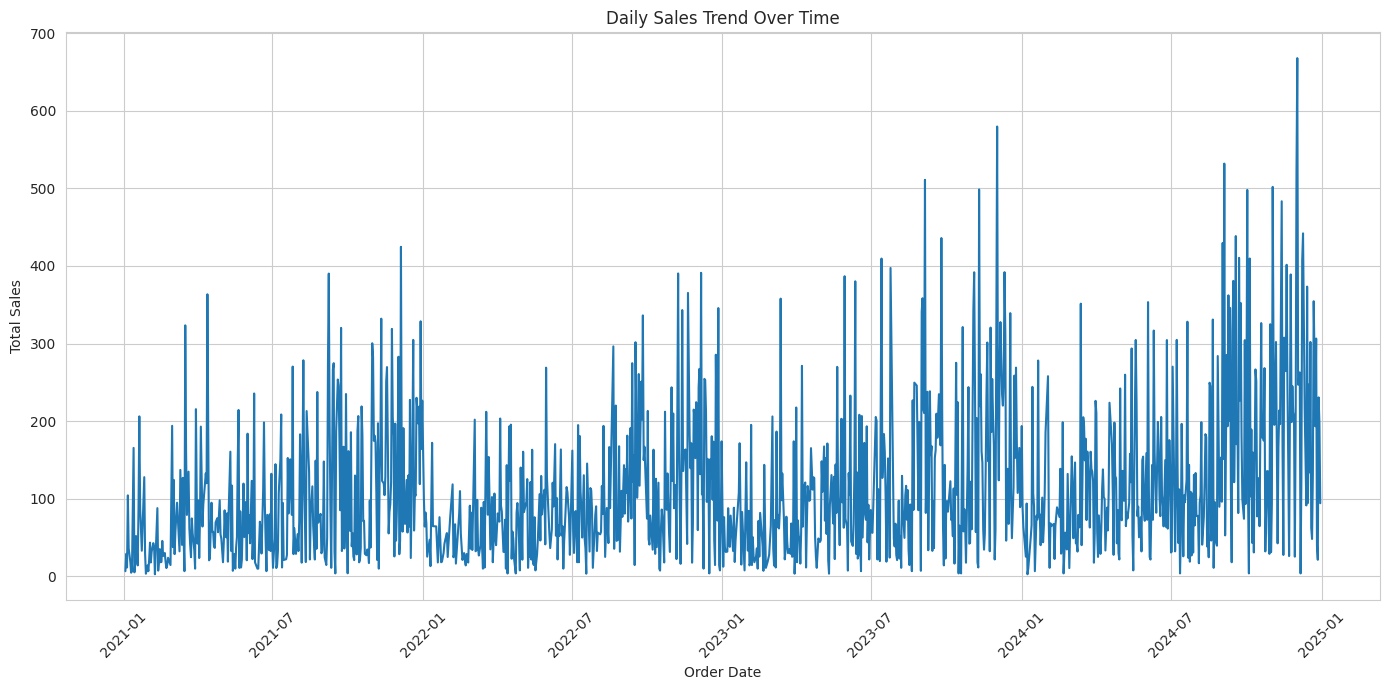

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')

# --- 1. Sales Trend Over Time ---

# Aggregate daily sales
daily_sales = sales.groupby('Order Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='Order Date', y='Sales', data=daily_sales)
plt.title('Daily Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Sales Analysis

/tmp/ipykernel_4583/4263993359.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Order Month', y='Sales', data=monthly_sales, palette='viridis')


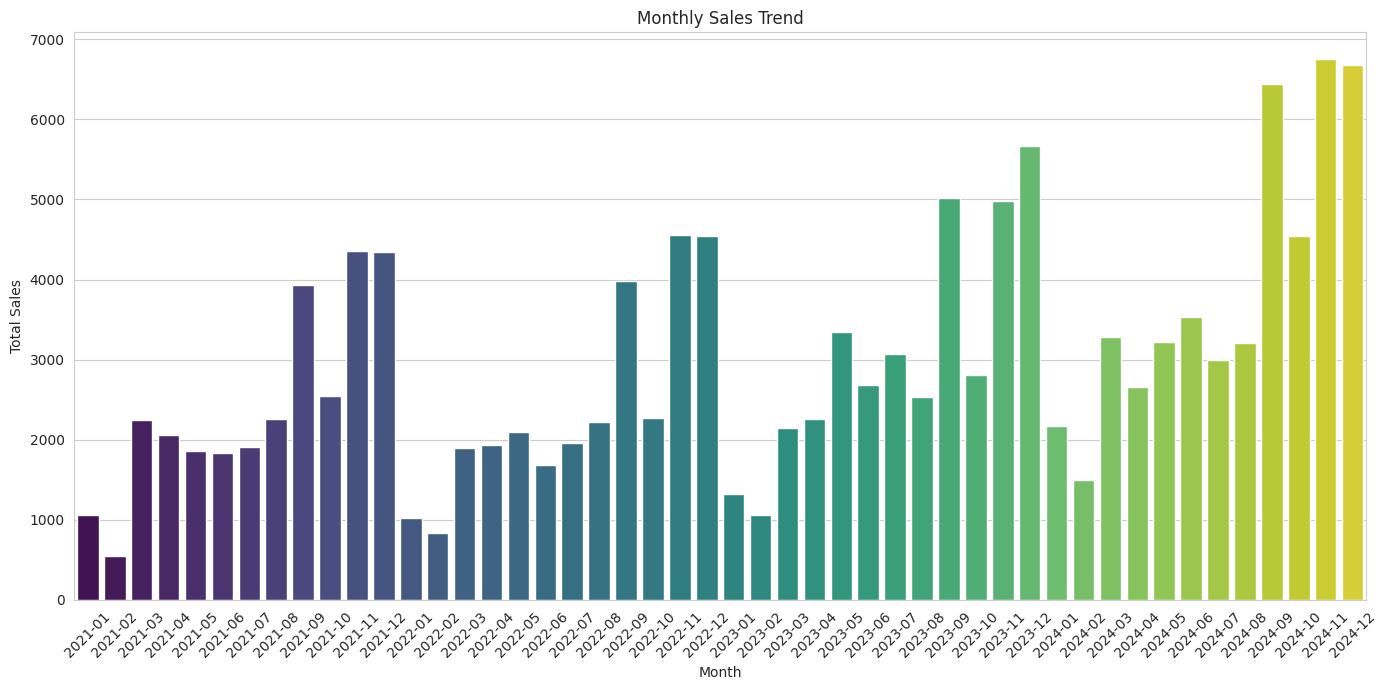

In [ ]:
sales['Order Month'] = sales['Order Date'].dt.to_period('M')
monthly_sales = sales.groupby('Order Month')['Sales'].sum().reset_index()
monthly_sales['Order Month'] = monthly_sales['Order Month'].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(x='Order Month', y='Sales', data=monthly_sales, palette='viridis')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Region Analysis: Sales and Profit

/tmp/ipykernel_4583/649017914.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=region_performance.sort_values('Sales', ascending=False), palette='coolwarm', ax=axes[0])
/tmp/ipykernel_4583/649017914.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Profit', data=region_performance.sort_values('Profit', ascending=False), palette='coolwarm', ax=axes[1])


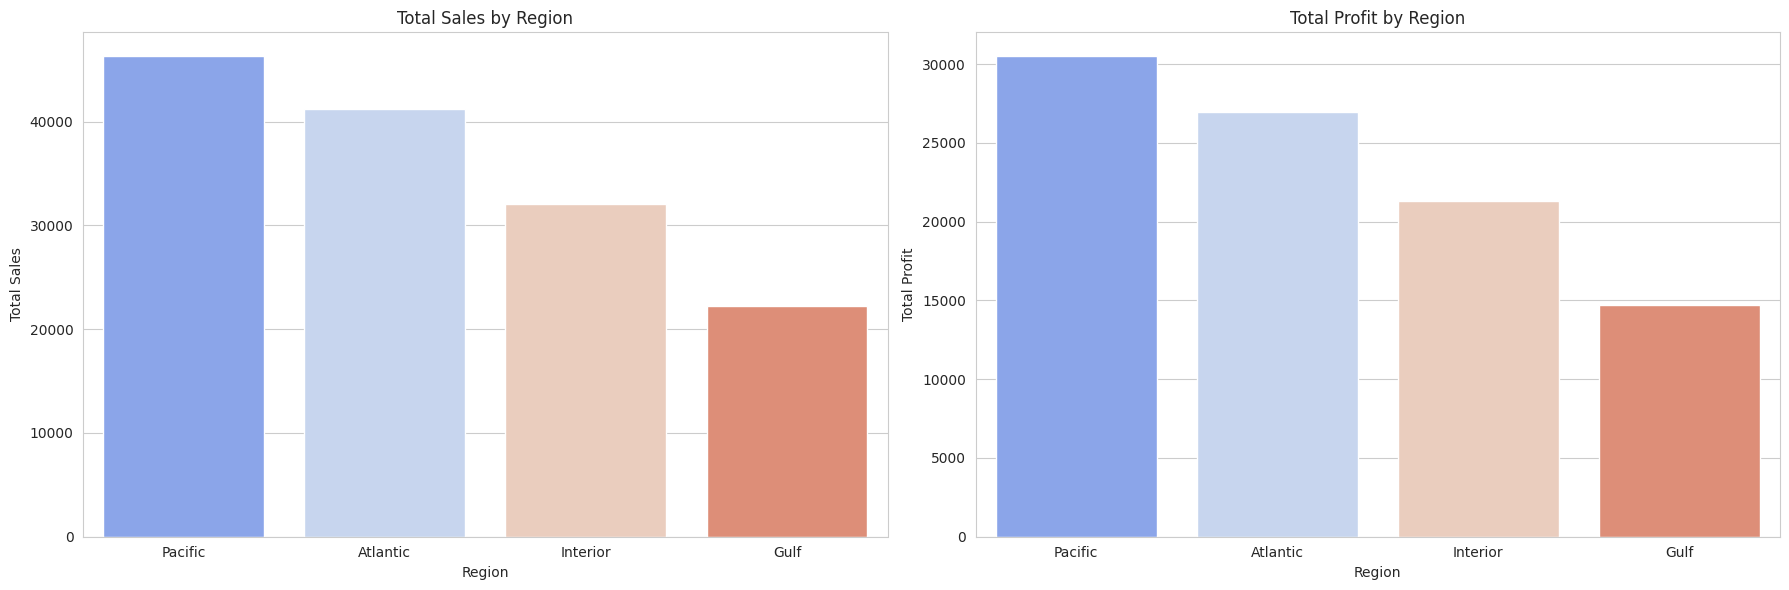

In [ ]:
region_performance = sales.groupby('Region').agg(
    Sales=('Sales', 'sum'),
    Profit=('Gross Profit', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Region', y='Sales', data=region_performance.sort_values('Sales', ascending=False), palette='coolwarm', ax=axes[0])
axes[0].set_title('Total Sales by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales')

sns.barplot(x='Region', y='Profit', data=region_performance.sort_values('Profit', ascending=False), palette='coolwarm', ax=axes[1])
axes[1].set_title('Total Profit by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

### Product Analysis: Top and Bottom Products


--- Top 10 Products by Sales ---


,Product Name,Sales,Profit
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50
10,Wonka Bar - Milk Chocolate,26867.75,17443.37
9,Wonka Bar - Fudge Mallows,24890.40,16593.60
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95
6,Lickable Wallpaper,7860.00,3930.00
4,Kazookles,1205.75,92.75
14,Wonka Gum,597.50,310.70
0,Everlasting Gobstopper,130.00,104.00
1,Fizzy Lifting Drinks,78.75,47.25



--- Bottom 10 Products by Sales ---


,Product Name,Sales,Profit
2,Fun Dip,12.00,4.80
7,Nerds,15.00,7.00
5,Laffy Taffy,53.73,33.48
8,SweeTARTS,61.50,28.70
3,Hair Toffee,76.50,59.50
1,Fizzy Lifting Drinks,78.75,47.25
0,Everlasting Gobstopper,130.00,104.00
14,Wonka Gum,597.50,310.70
4,Kazookles,1205.75,92.75
6,Lickable Wallpaper,7860.00,3930.00



--- Top 10 Products by Profit ---


,Product Name,Sales,Profit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20
10,Wonka Bar - Milk Chocolate,26867.75,17443.37
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95
9,Wonka Bar - Fudge Mallows,24890.40,16593.60
6,Lickable Wallpaper,7860.00,3930.00
14,Wonka Gum,597.50,310.70
0,Everlasting Gobstopper,130.00,104.00
4,Kazookles,1205.75,92.75
3,Hair Toffee,76.50,59.50



--- Bottom 10 Products by Profit ---


,Product Name,Sales,Profit
2,Fun Dip,12.00,4.80
7,Nerds,15.00,7.00
8,SweeTARTS,61.50,28.70
5,Laffy Taffy,53.73,33.48
1,Fizzy Lifting Drinks,78.75,47.25
3,Hair Toffee,76.50,59.50
4,Kazookles,1205.75,92.75
0,Everlasting Gobstopper,130.00,104.00
14,Wonka Gum,597.50,310.70
6,Lickable Wallpaper,7860.00,3930.00


/tmp/ipykernel_4583/2545884316.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=top_10_products_sales, palette='Greens_r', ax=axes[0])
/tmp/ipykernel_4583/2545884316.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=bottom_10_products_sales, palette='Reds', ax=axes[1])


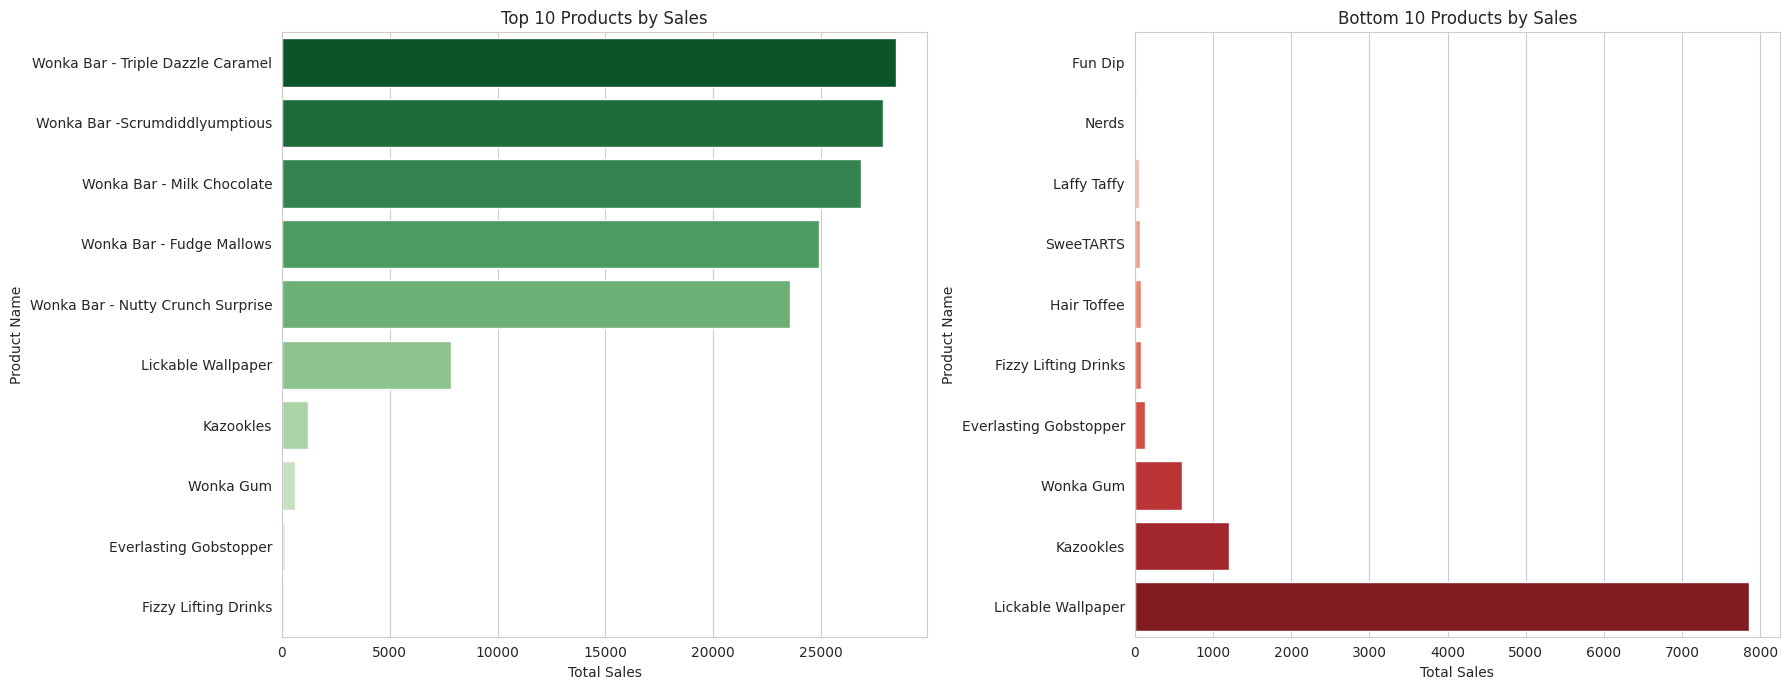

In [ ]:
product_performance = sales.groupby('Product Name').agg(
    Sales=('Sales', 'sum'),
    Profit=('Gross Profit', 'sum')
).reset_index()

top_10_products_sales = product_performance.sort_values('Sales', ascending=False).head(10)
bottom_10_products_sales = product_performance.sort_values('Sales', ascending=True).head(10)

top_10_products_profit = product_performance.sort_values('Profit', ascending=False).head(10)
bottom_10_products_profit = product_performance.sort_values('Profit', ascending=True).head(10)

print("\n--- Top 10 Products by Sales ---")
display(top_10_products_sales)

print("\n--- Bottom 10 Products by Sales ---")
display(bottom_10_products_sales)

print("\n--- Top 10 Products by Profit ---")
display(top_10_products_profit)

print("\n--- Bottom 10 Products by Profit ---")
display(bottom_10_products_profit)

# Plotting top and bottom products by sales
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x='Sales', y='Product Name', data=top_10_products_sales, palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Products by Sales')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Product Name')

sns.barplot(x='Sales', y='Product Name', data=bottom_10_products_sales, palette='Reds', ax=axes[1])
axes[1].set_title('Bottom 10 Products by Sales')
axes[1].set_xlabel('Total Sales')
axes[1].set_ylabel('Product Name')

plt.tight_layout()
plt.show()

### Factory Analysis: Sales and Profit

/tmp/ipykernel_4583/745412690.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Factory', y='Sales', data=factory_performance.sort_values('Sales', ascending=False), palette='Blues_r', ax=axes[0])
/tmp/ipykernel_4583/745412690.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Factory', y='Profit', data=factory_performance.sort_values('Profit', ascending=False), palette='Blues_r', ax=axes[1])


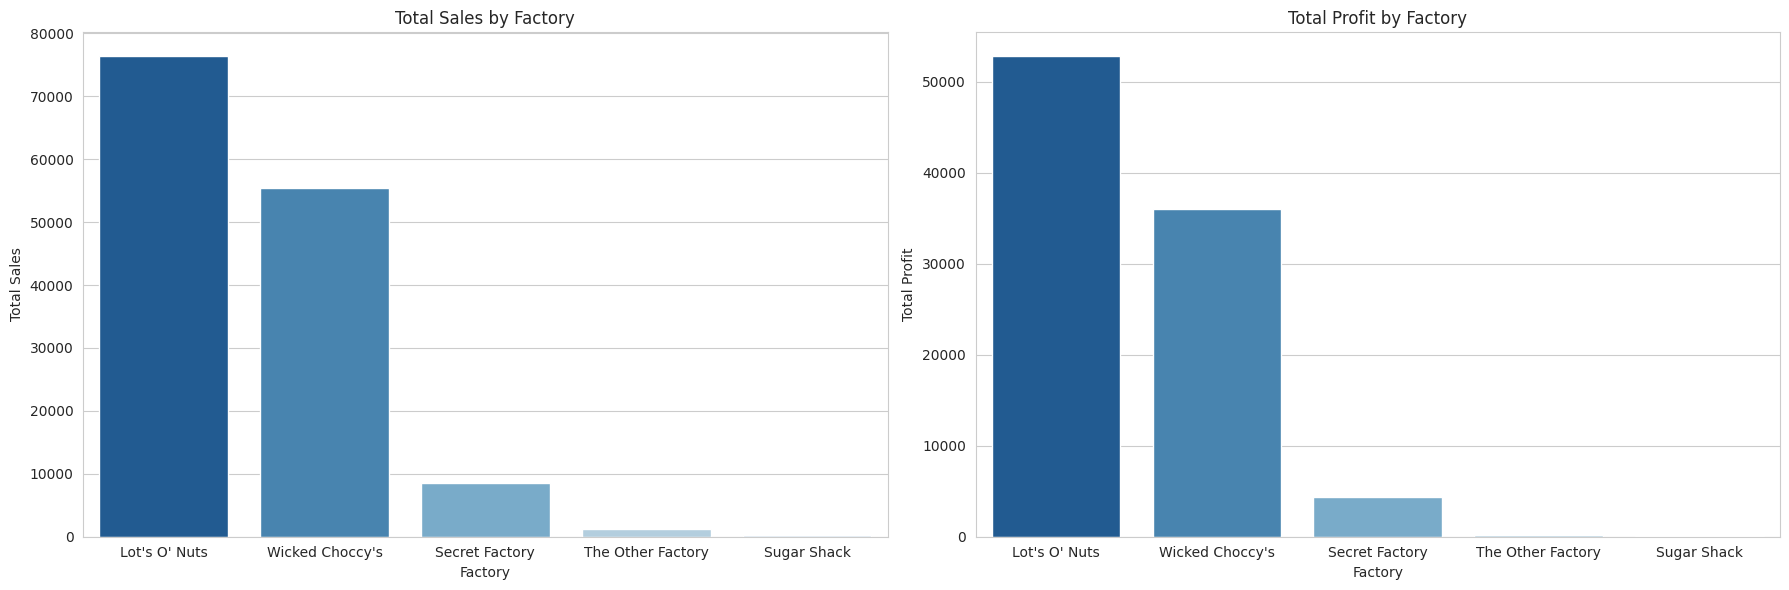

In [ ]:
factory_performance = sales.groupby('Factory').agg(
    Sales=('Sales', 'sum'),
    Profit=('Gross Profit', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Factory', y='Sales', data=factory_performance.sort_values('Sales', ascending=False), palette='Blues_r', ax=axes[0])
axes[0].set_title('Total Sales by Factory')
axes[0].set_xlabel('Factory')
axes[0].set_ylabel('Total Sales')

sns.barplot(x='Factory', y='Profit', data=factory_performance.sort_values('Profit', ascending=False), palette='Blues_r', ax=axes[1])
axes[1].set_title('Total Profit by Factory')
axes[1].set_xlabel('Factory')
axes[1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()

### Customer Analysis: Top Cities, States, and Customers by Sales


--- Top 10 Cities by Sales ---


,City,Sales
0,New York City,12514.90
1,Los Angeles,10408.75
2,Philadelphia,7415.52
3,San Francisco,7018.61
4,Seattle,5893.39
5,Houston,5429.41
6,Chicago,4263.92
7,Columbus,3357.39
8,Springfield,2375.00
9,San Diego,2348.88



--- Top 10 States by Sales ---


,State/Province,Sales
0,California,27917.40
1,New York,15541.03
2,Texas,13416.09
3,Pennsylvania,8027.03
4,Washington,6921.15
5,Illinois,6898.96
6,Ohio,6768.95
7,Florida,4804.02
8,Arizona,3587.55
9,North Carolina,3450.86



--- Top 10 Customers by Sales ---


,Customer ID,Sales
0,131807,454.40
1,115238,380.50
2,122336,352.20
3,164756,304.14
4,124163,247.35
5,164770,232.40
6,125388,216.00
7,163790,208.95
8,164147,204.65
9,140326,202.05


/tmp/ipykernel_4583/1084335818.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='City', data=top_cities, palette='Purples_r')


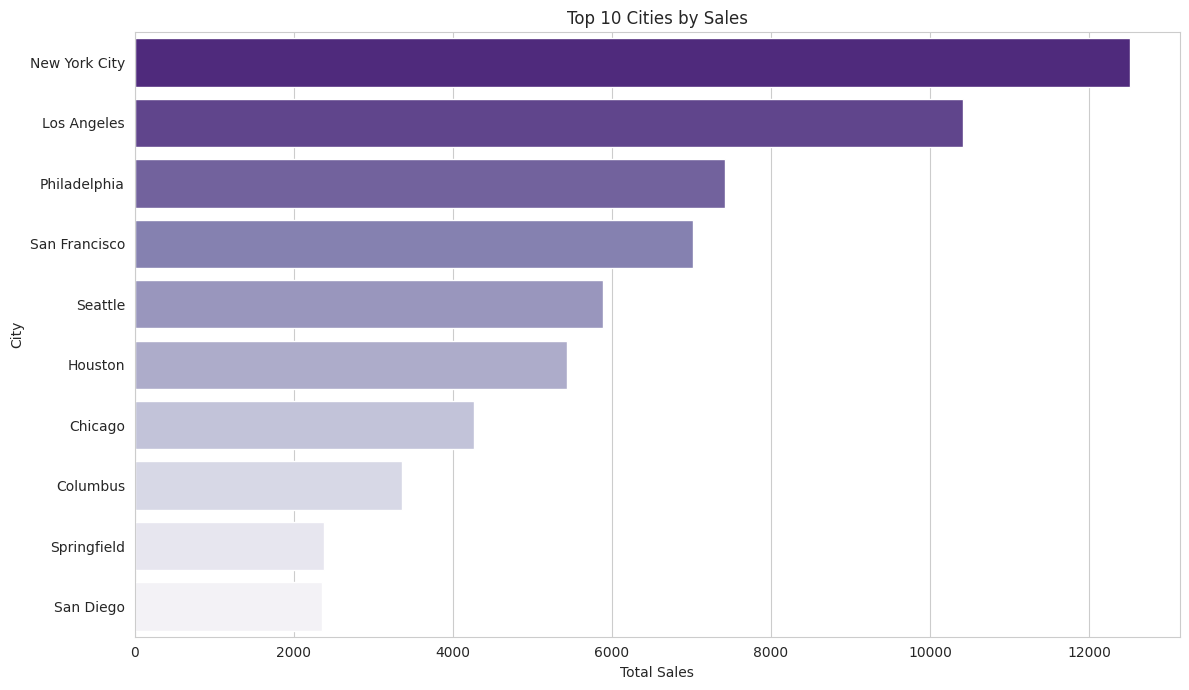

/tmp/ipykernel_4583/1084335818.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='State/Province', data=top_states, palette='Oranges_r')


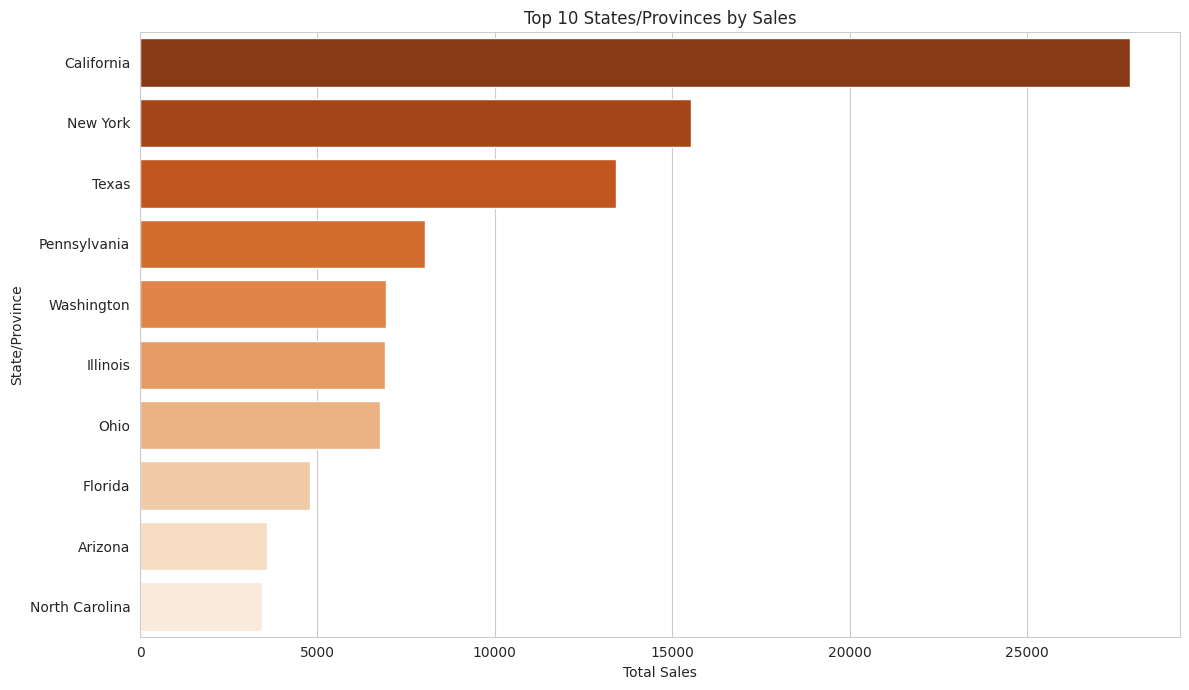

/tmp/ipykernel_4583/1084335818.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Customer ID', data=top_customers, palette='Greys_r')


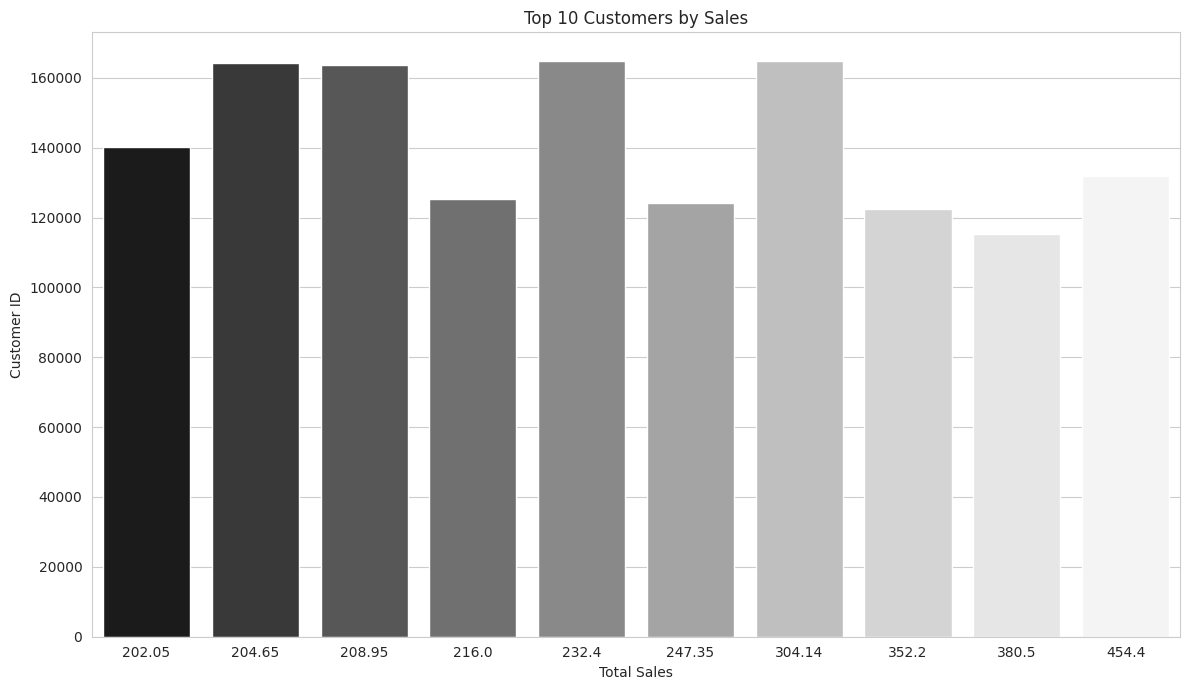

In [ ]:
top_cities = sales.groupby('City')['Sales'].sum().nlargest(10).reset_index()
top_states = sales.groupby('State/Province')['Sales'].sum().nlargest(10).reset_index()
top_customers = sales.groupby('Customer ID')['Sales'].sum().nlargest(10).reset_index()

print("\n--- Top 10 Cities by Sales ---")
display(top_cities)

print("\n--- Top 10 States by Sales ---")
display(top_states)

print("\n--- Top 10 Customers by Sales ---")
display(top_customers)


# Plotting top cities by sales
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales', y='City', data=top_cities, palette='Purples_r')
plt.title('Top 10 Cities by Sales')
plt.xlabel('Total Sales')
plt.ylabel('City')
plt.tight_layout()
plt.show()

# Plotting top states by sales
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales', y='State/Province', data=top_states, palette='Oranges_r')
plt.title('Top 10 States/Provinces by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State/Province')
plt.tight_layout()
plt.show()

# Plotting top customers by sales
plt.figure(figsize=(12, 7))
sns.barplot(x='Sales', y='Customer ID', data=top_customers, palette='Greys_r')
plt.title('Top 10 Customers by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

In [ ]:
sales.to_csv('cleaned_sales.csv', index=False)